In [1]:
import xradar as xd
import fsspec
import matplotlib.pyplot as plt
import wradlib as wrl
import xarray as xr
import numpy as np
from datetime import datetime

In [2]:
def create_query(date, radar_site):
    """
    Create a query string for IDEAM radar files in the AWS bucket,
    handling custom filename formats per radar site.

    Parameters:
        date (datetime.datetime or datetime.date)
        radar_site (str): e.g., "Bogota", "Munchique", "Santa_Elena"

    Returns:
        str: Full S3-like path to the radar data
    """
    from datetime import datetime

    site_prefix = radar_site[:3].upper()
    base_path = f"l2_data/{date:%Y/%m/%d}/{radar_site}/"

    # Normalize radar site name for matching
    site_key = radar_site.lower().replace(" ", "_")

    if isinstance(date, datetime):
        has_hour = True
    else:
        has_hour = False

    # Define custom filename formats
    formats = {
        "bogota": lambda d: f"1399BOG-{d:%Y%m%d-%H}",
        "munchique": lambda d: f"CEM{d:%y%m%d%H}",
        "santa_elena": lambda d: f"9100SAN-{d:%Y%m%d-%H}"
    }

    if has_hour and site_key in formats:
        filename = formats[site_key](date)
    else:
        # Fallback: SITEyymmdd or SITEyymmddHH
        timestamp = f"{date:%y%m%d%H}" if has_hour else f"{date:%y%m%d}"
        filename = f"{site_prefix}{timestamp}"

    return f"{base_path}{filename}"
    

def download_s3file(s3_path: str)-> str:
    return fsspec.open_local(
            f"simplecache::s3://{s3_path}",
            s3={"anon": True},
            filecache={"cache_storage": "."},
        )


In [3]:
date_query = datetime(2025, 3, 29, 1)
radar_name = "Barrancabermeja"
query = create_query(date=date_query, radar_site=radar_name)

In [4]:
date_query

datetime.datetime(2025, 3, 29, 1, 0)

In [5]:
query

'l2_data/2025/03/29/Barrancabermeja/BAR25032901'

In [6]:
fs = fsspec.filesystem("s3", anon=True)
radars = ["Barrancabermeja", "Bogota", "Carimagua", "Corozal", "Guaviare", "Munchique", "Tablazo", "santa_elena"]
dt_files = {}
for radar in radars:
    query = create_query(date=date_query, radar_site=radar)
    dt_files[radar] = ['s3://' + f for f in 
              sorted(fs.glob(f"s3-radaresideam/{query}*"))
             ]

In [7]:
dt_files.keys()

dict_keys(['Barrancabermeja', 'Bogota', 'Carimagua', 'Corozal', 'Guaviare', 'Munchique', 'Tablazo', 'santa_elena'])

### IDIGER

In [8]:
dt_bog = xd.io.open_cfradial1_datatree(
    download_s3file(dt_files["Bogota"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:01 UTC')

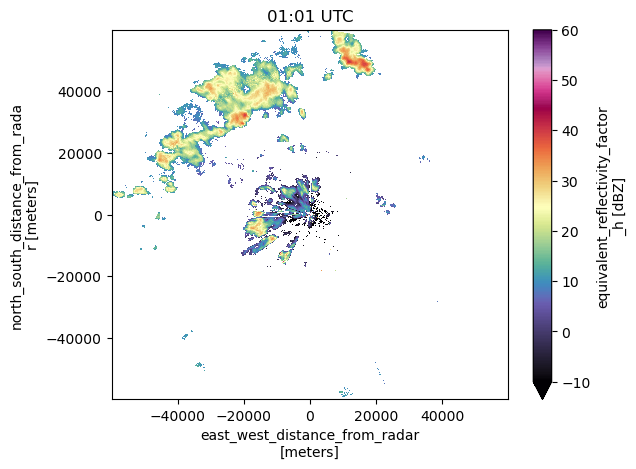

In [9]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_bog['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_bog['sweep_0'].time.min().dt.strftime(tformat).values)

### TABLAZO

In [10]:
dt_tab = xd.io.open_iris_datatree(
    download_s3file(dt_files["Tablazo"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

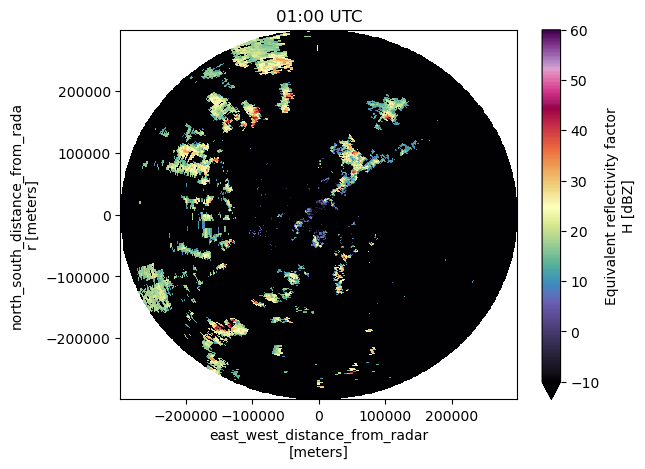

In [11]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_tab['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_tab['sweep_0'].time.min().dt.strftime(tformat).values)

### Barranca

In [12]:
dt_bar = xd.io.open_iris_datatree(
    download_s3file(dt_files["Barrancabermeja"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

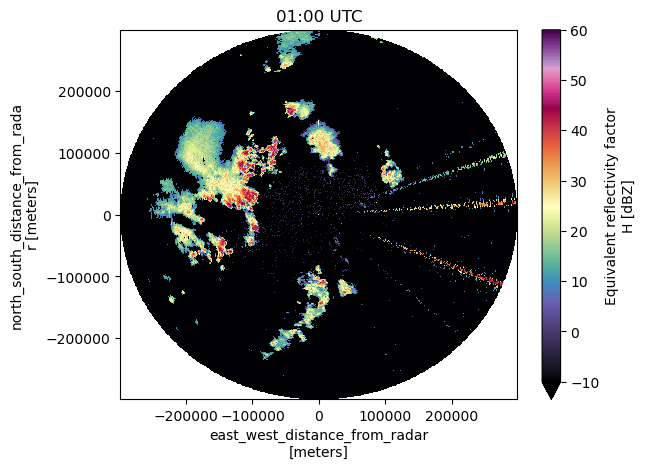

In [13]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_bar['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_bar['sweep_0'].time.min().dt.strftime(tformat).values)

### Carimagua

In [14]:
dt_car = xd.io.open_iris_datatree(
    download_s3file(dt_files["Carimagua"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

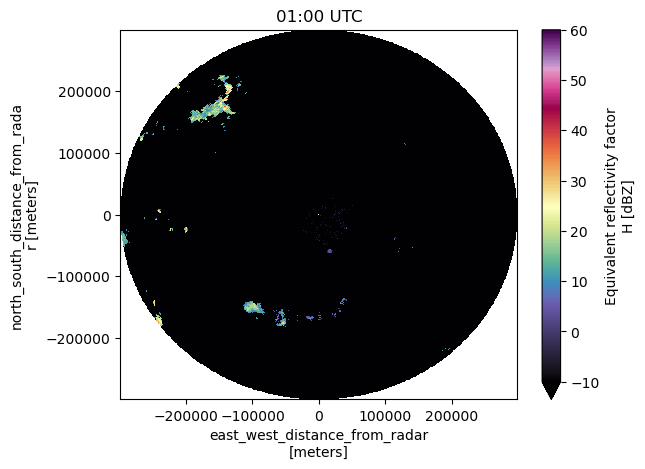

In [15]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_car['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_car['sweep_0'].time.min().dt.strftime(tformat).values)

### Guaviare

In [16]:
dt_gua = xd.io.open_iris_datatree(
    download_s3file(dt_files["Guaviare"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

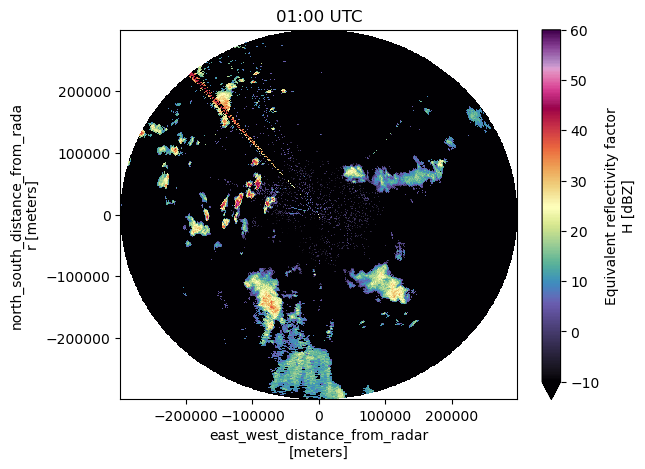

In [17]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_gua['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_gua['sweep_0'].time.min().dt.strftime(tformat).values)

### Munchique

In [18]:
dt_cem = xd.io.open_iris_datatree(
    download_s3file(dt_files["Munchique"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

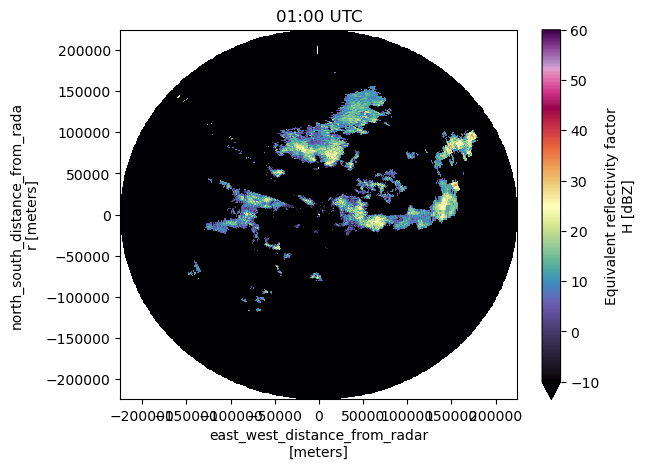

In [19]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_cem['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_cem['sweep_0'].time.min().dt.strftime(tformat).values)

### Corozal

In [20]:
dt_cor = xd.io.open_iris_datatree(
    download_s3file(dt_files["Corozal"][0])
    ).xradar.georeference()

Text(0.5, 1.0, '01:00 UTC')

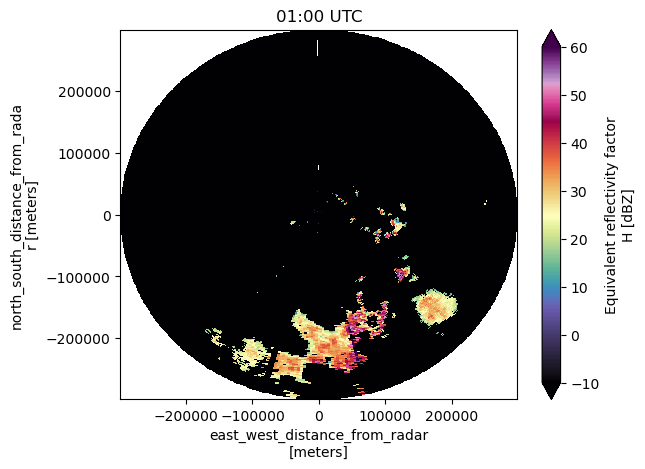

In [21]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_cor['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
axs.set_title(dt_cor['sweep_0'].time.min().dt.strftime(tformat).values)

### SIATA- Santa Elena

In [22]:
dt_siata = xd.io.open_cfradial1_datatree(
    download_s3file(dt_files["santa_elena"][0]), 
    decode_times=False
    ).xradar.georeference()

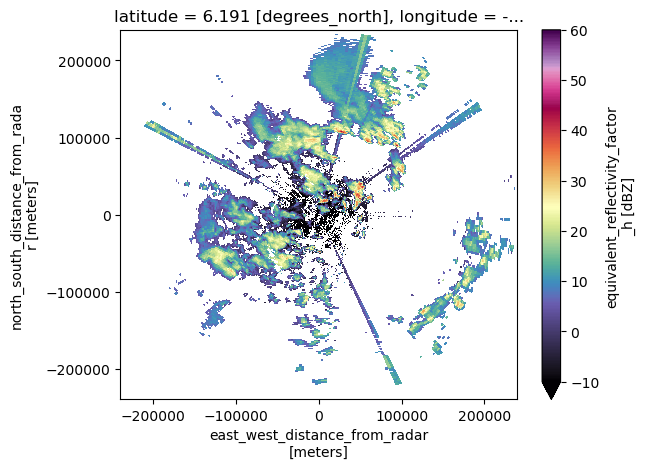

In [24]:
fig, axs = plt.subplots()
vmin, vmax = -10, 60
cmap = "ChaseSpectral"
tformat = "%H:%M UTC"  # adjust if needed

# Plot CAR
p1 = dt_siata['sweep_0'].DBZH.plot(
    cmap=cmap,
    vmax=vmax,
    vmin=vmin,
    x="x",
    y="y",
    ax=axs,
    # add_colorbar=False
)
# axs.set_title(dt_siata['sweep_0'].time.min().dt.strftime(tformat).values)